── LOADING DATA ──
✓ Data loaded
Fitting GJR-GARCH(1,1,1)...

── GJR-GARCH(1,1,1) FITTED PARAMETERS ──
mu          0.054906
omega       0.044216
alpha[1]    0.000000
gamma[1]    0.180209
beta[1]     0.849023

  α (arch[1])  = ARCH effect: impact of past shock
  γ (gamma[1]) = Leverage: EXTRA vol from negative shocks
  β (beta[1])  = GARCH persistence
  Stationarity check (α + γ/2 + β < 1):
    α + γ/2 + β = 0.9391 → ✓ Stationary

✓ GJR-GARCH volatility calculated
✓ Merged rows: 250
✓ Black-Scholes deltas calculated (verification)

✓ Dynamic Thresholds (GJR-GARCH-based)
  Lower (SHORT_STRADDLE signal) : -0.0089
  Upper (LONG_STRADDLE signal)  : 0.0261

✓ Signals generated
  {'HOLD/NONE': 23, 'SHORT_STRADDLE': 14, 'LONG_STRADDLE': 13}
✓ Delta hedging calculated
✓ Strategy and benchmarks calculated

── TRADE RESULTS (GJR-GARCH Strategy, last 10 trades) ──
      Date         signal  entry_price  exit_price  straddle_pnl  hedge_pnl  transaction_cost    Net PnL  Cumulative PnL
2025-08-04 SHO

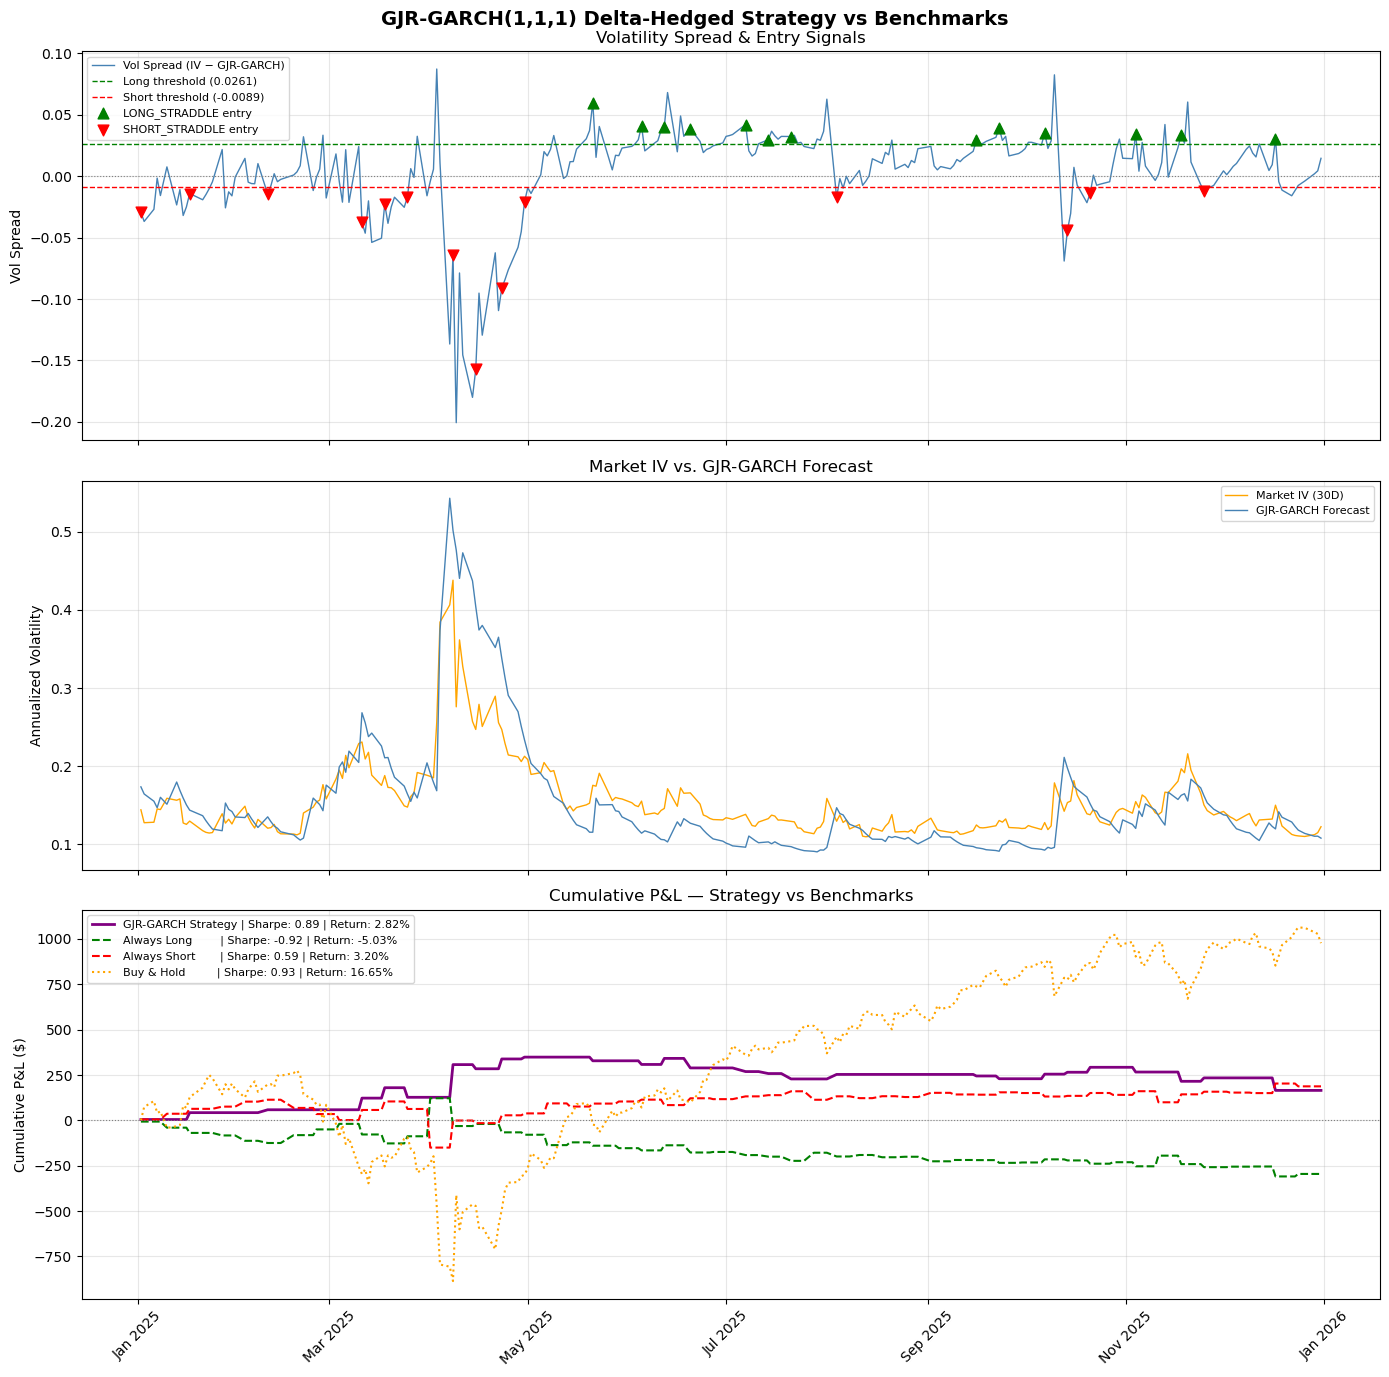


✓ Plot saved as gjr_garch_benchmarks.png


In [2]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║            GJR-GARCH(1,1,1) DELTA-HEDGED STRADDLE STRATEGY                 ║
║                                                                              ║
║  What is GJR-GARCH?                                                          ║
║  ─────────────────                                                           ║
║  GJR-GARCH (Glosten-Jagannathan-Runkle GARCH) extends standard GARCH by     ║
║  adding an asymmetry term that captures the "leverage effect":               ║
║  bad news (negative returns) increases volatility MORE than equally-sized    ║
║  good news. This is empirically well-documented in equity markets.           ║
║                                                                              ║
║  The variance equation is:                                                   ║
║    σ²_t = ω + α·ε²_{t-1} + γ·ε²_{t-1}·I_{t-1} + β·σ²_{t-1}               ║
║                                                                              ║
║  Where:                                                                      ║
║    ω  = long-run variance constant                                           ║
║    α  = ARCH term (impact of past squared shocks)                           ║
║    γ  = GJR leverage term (EXTRA impact when shock was negative)             ║
║    β  = GARCH term (persistence of past variance)                            ║
║    I  = indicator = 1 if ε_{t-1} < 0, else 0                               ║
║                                                                              ║
║  vs EGARCH:                                                                  ║
║    EGARCH models log(σ²) → always positive, no constraints needed            ║
║    GJR-GARCH models σ² directly → requires α + γ/2 + β < 1 for stationarity ║
║    GJR-GARCH is generally faster to fit and easier to interpret              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

import pandas as pd
import numpy as np
from scipy.stats import norm
from arch import arch_model
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ══════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ══════════════════════════════════════════════════════════════════════════════
CYCLE_LENGTH        = 5       # 5-day (weekly) hold cycle
IV_COL              = 'IV_30D=(B2+C2)/2'
STRADDLE_COL        = '30D Constant-Maturity Straddle'
TRANS_COST          = 0.001   # 0.1% transaction cost on straddle mid-price
BID_ASK_SPREAD      = 0.002   # 0.2% half bid-ask spread
BID_ASK_TEST_VALUES = [0.001, 0.002, 0.003, 0.005, 0.010]

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
print("── LOADING DATA ──")
df_25       = pd.read_csv('SPY_Close_modeling_2.5y.csv')
df_05       = pd.read_csv('SPY_Close_forecast_0.5y.csv')
iv_df       = pd.read_excel('options_data_2025.xlsx', sheet_name='IV')
delta_df    = pd.read_excel('options_data_2025.xlsx', sheet_name='Delta_Trading')
straddle_df = pd.read_excel('options_data_2025.xlsx', sheet_name='Straddle')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — COMBINE & SORT PRICE DATA
# ══════════════════════════════════════════════════════════════════════════════
df = pd.concat([df_25, df_05], axis=0).reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

iv_df['Date']       = pd.to_datetime(iv_df['Date'])
delta_df['Date']    = pd.to_datetime(delta_df['Date'])
straddle_df['Date'] = pd.to_datetime(straddle_df['Date'])
print("✓ Data loaded")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — GJR-GARCH VOLATILITY (FULL-SAMPLE, IN-SAMPLE FIT)
# ══════════════════════════════════════════════════════════════════════════════
def get_gjr_garch_forecast(df: pd.DataFrame, col_name: str,
                           p: int = 1, q: int = 1, o: int = 1) -> pd.Series:
    """
    Fits a single GJR-GARCH(1,1,1) model over the entire sample and returns
    the in-sample annualized conditional volatility at each date.

    Parameters:
        df       : DataFrame containing the return column
        col_name : Column of log returns (e.g. 'log_return'), as decimals
        p        : ARCH order — how many lags of squared shocks to include.
                   p=1 means only yesterday's shock matters. Default = 1.
        q        : GARCH order — how many lags of past variance to include.
                   q=1 captures the persistence of volatility clustering. Default = 1.
        o        : GJR leverage order — how many lags of negative shocks get
                   the asymmetry treatment. o=1 is standard. Default = 1.

    Returns:
        pd.Series of annualized GJR-GARCH conditional volatility, aligned to df.index.

    Notes:
        ─ Returns are scaled to % (×100) for numerical stability of the optimizer.
          The arch library works best when the series has variance ~1–5 rather
          than 0.0001 (which you'd get from decimal daily returns).
        ─ conditional_volatility from arch is in the SAME units as the input,
          so we divide by 100 to get back to decimal, then annualize with √252.
        ─ GJR-GARCH stationarity condition: α + γ/2 + β < 1.
          The arch library enforces this automatically during fitting.
        ─ In-sample fit (not rolling) mirrors the approach in your EGARCH script #2.
          For a rolling/walk-forward version, see get_gjr_garch_rolling() below.
    """
    TRADING_DAYS = 252
    returns = df[col_name] * 100  # scale to % — critical for optimizer stability

    # vol='GARCH' with o > 0 activates the GJR (asymmetry) extension.
    # This is different from vol='EGARCH' which uses the log-variance form.
    model = arch_model(
        returns,
        vol='GARCH',    # standard GARCH variance equation (σ² ≥ 0 constrained)
        p=p,            # ARCH lags (sensitivity to recent shocks)
        o=o,            # GJR leverage lags (extra weight on negative shocks)
        q=q,            # GARCH lags (variance persistence)
        dist='normal'   # error distribution — can also use 't' for fat tails
    )
    res = model.fit(disp='off', show_warning=False)

    # Print fitted parameters so you can inspect the leverage effect (gamma)
    print("\n── GJR-GARCH(1,1,1) FITTED PARAMETERS ──")
    print(res.params.to_string())
    print(f"\n  α (arch[1])  = ARCH effect: impact of past shock")
    print(f"  γ (gamma[1]) = Leverage: EXTRA vol from negative shocks")
    print(f"  β (beta[1])  = GARCH persistence")
    print(f"  Stationarity check (α + γ/2 + β < 1):")
    try:
        alpha = res.params['alpha[1]']
        gamma = res.params['gamma[1]']
        beta  = res.params['beta[1]']
        stat_sum = alpha + gamma / 2 + beta
        print(f"    α + γ/2 + β = {stat_sum:.4f} → {'✓ Stationary' if stat_sum < 1 else '✗ Non-stationary!'}")
    except KeyError:
        print("    (Parameter names differ — check res.params above)")

    # conditional_volatility is the fitted daily σ in % units
    # Divide by 100 to convert back to decimal, then annualize
    daily_vol  = res.conditional_volatility / 100
    annual_vol = daily_vol * np.sqrt(TRADING_DAYS)

    return pd.Series(annual_vol.values, index=df.index)


# ── OPTIONAL: Rolling / Walk-Forward GJR-GARCH ────────────────────────────────
def get_gjr_garch_rolling(df: pd.DataFrame, col_name: str,
                          p: int = 1, q: int = 1, o: int = 1,
                          rolling_window: int = 30) -> pd.Series:
    """
    Fits GJR-GARCH(1,1,1) in a rolling (walk-forward) fashion:
    at each time step t, the model is re-fitted using only data up to t-1,
    then produces a 1-step-ahead forecast for time t.

    This avoids look-ahead bias — the model at time t never sees future data.
    It mirrors the rolling EGARCH in your script #1.

    Parameters:
        rolling_window : Minimum training days before first forecast. Default = 30.

    Returns:
        pd.Series of 1-step-ahead annualized forecasts. NaN before rolling_window.

    Performance note:
        This re-fits the model n - rolling_window times, so it's slow for large n.
        For ~750 rows it may take 1–3 minutes.
    """
    TRADING_DAYS = 252
    returns  = df[col_name].values * 100
    n        = len(returns)
    forecasts = np.full(n, np.nan)

    for t in range(rolling_window, n):
        train = returns[:t]   # only past data — no look-ahead
        try:
            model = arch_model(train, vol='GARCH', p=p, o=o, q=q, dist='normal')
            res   = model.fit(disp='off', show_warning=False)

            # forecast(horizon=1) gives the 1-step-ahead variance
            fc = res.forecast(horizon=1, reindex=False)
            daily_var_pct = fc.variance.values[-1, 0]   # in %² units

            # Convert %² → decimal² → annualize
            annual_vol = np.sqrt(daily_var_pct / 100**2 * TRADING_DAYS)
            forecasts[t] = annual_vol

        except Exception:
            forecasts[t] = np.nan   # if optimizer fails, carry NaN

    return pd.Series(forecasts, index=df.index)


# ── RUN THE MODEL ─────────────────────────────────────────────────────────────
# Using in-sample fit (fast, matches script #2 / #3 approach).
# Swap to get_gjr_garch_rolling() if you want walk-forward / no look-ahead.
print("Fitting GJR-GARCH(1,1,1)...")
df['forecast_vol'] = get_gjr_garch_forecast(df, col_name='log_return', p=1, q=1, o=1)
print("\n✓ GJR-GARCH volatility calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — MERGE ALL DATA
# ══════════════════════════════════════════════════════════════════════════════
# Merge IV data with GJR-GARCH forecasts
merged_df = pd.merge(iv_df, df[['Date', 'close', 'forecast_vol']], on='Date', how='inner')

# Merge in delta/hedge data from Delta_Trading sheet
merged_df = pd.merge(
    merged_df,
    delta_df[['Date', 'Underlying (SPX Spot)', 'ATM Strike',
              'RF_1M/100', 'DTE_F = FrontExp - Date',
              'Call Delta（Trading）', 'Put Delta (Trading)',
              'Straddle Delta']],
    on='Date', how='inner'
)

# Merge in straddle price and PnL data
merged_df = pd.merge(
    merged_df,
    straddle_df[['Date', STRADDLE_COL, 'PnL', 'Return']],
    on='Date', how='inner'
)
print(f"✓ Merged rows: {len(merged_df)}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — BLACK-SCHOLES DELTAS (VERIFICATION)
# ══════════════════════════════════════════════════════════════════════════════
def calculate_bs_deltas(row):
    """
    Computes Black-Scholes call/put/straddle deltas for verification.
    These should closely match the trading deltas in the Delta_Trading sheet.
    """
    S          = row['Underlying (SPX Spot)']
    K          = row['ATM Strike']
    r          = row['RF_1M/100']
    T          = row['DTE_F = FrontExp - Date'] / 365
    sigma_call = row['IV_30D_Call(%)'] / 100
    sigma_put  = row['IV_30D_Put(%)']  / 100

    d1_call    = (np.log(S / K) + (r + 0.5 * sigma_call**2) * T) / (sigma_call * np.sqrt(T))
    delta_call = norm.cdf(d1_call)

    d1_put     = (np.log(S / K) + (r + 0.5 * sigma_put**2)  * T) / (sigma_put  * np.sqrt(T))
    delta_put  = norm.cdf(d1_put) - 1

    straddle_delta = delta_call + delta_put
    return pd.Series([delta_call, delta_put, straddle_delta])

merged_df[['BS_Call_Delta', 'BS_Put_Delta', 'BS_Straddle_Delta']] = merged_df.apply(
    calculate_bs_deltas, axis=1
)
print("✓ Black-Scholes deltas calculated (verification)")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — VOLATILITY SPREAD + DYNAMIC THRESHOLDS
# ══════════════════════════════════════════════════════════════════════════════
# vol_spread = how much market IV exceeds model's forecast
# Positive spread  → market pricing in MORE vol than GJR-GARCH expects → sell premium
# Negative spread  → market pricing in LESS vol than GJR-GARCH expects → buy vol
merged_df['vol_spread'] = merged_df[IV_COL] - merged_df['forecast_vol']

# Dynamic thresholds: use IQR (25th/75th percentile) rather than fixed values.
# This adapts to the overall vol regime of the sample period.
LOWER_THRESH = merged_df['vol_spread'].quantile(0.25)
UPPER_THRESH = merged_df['vol_spread'].quantile(0.75)

print(f"\n✓ Dynamic Thresholds (GJR-GARCH-based)")
print(f"  Lower (SHORT_STRADDLE signal) : {LOWER_THRESH:.4f}")
print(f"  Upper (LONG_STRADDLE signal)  : {UPPER_THRESH:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — 5-DAY CYCLE + TRADE SIGNALS
# ══════════════════════════════════════════════════════════════════════════════
# Each trade cycle is 5 trading days (≈ 1 calendar week).
# Day 1 = entry decision, Days 2–4 = hold + delta-hedge, Day 5 = exit.
merged_df['cycle_day']    = (np.arange(len(merged_df)) % CYCLE_LENGTH) + 1
merged_df['entry_signal'] = 'HOLD/NONE'

# Only generate signals on cycle Day 1
day_1_mask = (merged_df['cycle_day'] == 1)
merged_df.loc[day_1_mask & (merged_df['vol_spread'] > UPPER_THRESH), 'entry_signal'] = 'LONG_STRADDLE'
merged_df.loc[day_1_mask & (merged_df['vol_spread'] < LOWER_THRESH), 'entry_signal'] = 'SHORT_STRADDLE'

print(f"\n✓ Signals generated")
print(f"  {merged_df[day_1_mask]['entry_signal'].value_counts().to_dict()}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — DELTA HEDGING
# ══════════════════════════════════════════════════════════════════════════════
# Straddle delta = call delta + put delta.
# For a LONG straddle: we SHORT shares to hedge (offset the net delta).
# For a SHORT straddle: we LONG shares to hedge (offset the net delta).
# On exit day (cycle_day == 5): close all hedges (share_hedge_qty = 0).
merged_df['Straddle_Delta_Trading'] = (
    merged_df['Call Delta（Trading）'] + merged_df['Put Delta (Trading)']
)

# Forward-fill the active position from entry signal across the 5-day window
merged_df['active_pos'] = merged_df['entry_signal'].replace('HOLD/NONE', np.nan).ffill()

def calculate_share_hedge(row):
    """
    Computes the number of SPX shares to hold as a delta hedge.
    Negative = short shares (hedging a long straddle's positive delta).
    Positive = long shares  (hedging a short straddle's negative delta).
    """
    if row['cycle_day'] == 5:                  return 0   # exit: close hedge
    if row['active_pos'] == 'LONG_STRADDLE':   return -row['Straddle_Delta_Trading']
    if row['active_pos'] == 'SHORT_STRADDLE':  return  row['Straddle_Delta_Trading']
    return 0

merged_df['share_hedge_qty']   = merged_df.apply(calculate_share_hedge, axis=1)
merged_df['daily_hedge_trade'] = merged_df['share_hedge_qty'].diff().fillna(0)
merged_df.loc[merged_df['cycle_day'] == 1, 'daily_hedge_trade'] = merged_df['share_hedge_qty']
print("✓ Delta hedging calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — BACKTEST ENGINE
# ══════════════════════════════════════════════════════════════════════════════
def run_backtest(merged_df, signal_col, bid_ask, trans_cost,
                 straddle_col, always_signal=None):
    """
    Runs a 5-day cycle backtest for the straddle strategy.

    Parameters:
        signal_col    : Column containing 'LONG_STRADDLE' / 'SHORT_STRADDLE' / 'HOLD/NONE'
        bid_ask       : Half bid-ask spread applied to straddle entry/exit price
        trans_cost    : Transaction cost as fraction of mid-price (e.g. 0.001 = 0.1%)
        straddle_col  : Column with straddle mid-price
        always_signal : Override signal for benchmark runs ('LONG_STRADDLE' or 'SHORT_STRADDLE')

    Returns:
        DataFrame of trades with PnL components.

    PnL breakdown per trade:
        straddle_pnl = gain/loss from straddle price move (after bid-ask on entry & exit)
        hedge_pnl    = gain/loss from delta-hedge shares over the 5-day window
        trans_cost   = fixed friction cost at entry (% of straddle mid)
        Net PnL      = straddle_pnl + hedge_pnl - trans_cost

    Bid-ask logic:
        LONG  straddle: buy at mid × (1 + spread), sell at mid × (1 - spread)
        SHORT straddle: sell at mid × (1 - spread), buy back at mid × (1 + spread)
    """
    results = []

    for i in range(len(merged_df)):
        row = merged_df.iloc[i]
        if row['cycle_day'] != 1:
            continue

        signal = always_signal if always_signal else row[signal_col]
        if signal == 'HOLD/NONE':
            continue

        exit_idx = i + 4
        if exit_idx >= len(merged_df):
            continue

        exit_row  = merged_df.iloc[exit_idx]
        mid_entry = row[straddle_col]
        mid_exit  = exit_row[straddle_col]

        if signal == 'LONG_STRADDLE':
            entry_price  = mid_entry * (1 + bid_ask)   # pay the ask
            exit_price   = mid_exit  * (1 - bid_ask)   # hit the bid
            straddle_pnl = exit_price - entry_price
        else:  # SHORT_STRADDLE
            entry_price  = mid_entry * (1 - bid_ask)   # hit the bid to sell
            exit_price   = mid_exit  * (1 + bid_ask)   # pay the ask to close
            straddle_pnl = entry_price - exit_price     # profit if vol dropped

        # Accumulate hedge PnL across days 1–4
        hedge_pnl = 0
        if always_signal is None:   # benchmarks don't delta-hedge
            for d in range(i, min(i + 5, len(merged_df) - 1)):
                hedge_row    = merged_df.iloc[d]
                next_row     = merged_df.iloc[d + 1]
                price_change = (next_row['Underlying (SPX Spot)']
                                - hedge_row['Underlying (SPX Spot)'])
                hedge_pnl   += hedge_row['share_hedge_qty'] * price_change

        transaction_cost = mid_entry * trans_cost
        total_pnl        = straddle_pnl + hedge_pnl - transaction_cost

        results.append({
            'Date'            : row['Date'],
            'signal'          : signal,
            'entry_price'     : entry_price,
            'exit_price'      : exit_price,
            'straddle_pnl'    : straddle_pnl,
            'hedge_pnl'       : hedge_pnl,
            'transaction_cost': transaction_cost,
            'Net PnL'         : total_pnl,
            'vol_spread'      : row['vol_spread'],
            'forecast_vol'    : row['forecast_vol'],
            IV_COL            : row[IV_COL],
        })

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        results_df['Cumulative PnL'] = results_df['Net PnL'].cumsum()
    return results_df

# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — RUN STRATEGY + BENCHMARKS
# ══════════════════════════════════════════════════════════════════════════════
results_df      = run_backtest(merged_df, 'entry_signal', BID_ASK_SPREAD, TRANS_COST, STRADDLE_COL)
always_long_df  = run_backtest(merged_df, 'entry_signal', BID_ASK_SPREAD, TRANS_COST, STRADDLE_COL, always_signal='LONG_STRADDLE')
always_short_df = run_backtest(merged_df, 'entry_signal', BID_ASK_SPREAD, TRANS_COST, STRADDLE_COL, always_signal='SHORT_STRADDLE')

# Buy & Hold benchmark: just hold SPX spot
merged_df['buy_hold_pnl'] = merged_df['Underlying (SPX Spot)'].diff().fillna(0)
merged_df['cum_buy_hold'] = merged_df['buy_hold_pnl'].cumsum()

# Merge cumulative PnL back to daily timeline for plotting
for df_res, col in [
    (results_df,      'cum_strategy_pnl'),
    (always_long_df,  'cum_always_long'),
    (always_short_df, 'cum_always_short'),
]:
    merged_df = pd.merge(
        merged_df,
        df_res[['Date', 'Cumulative PnL']].rename(columns={'Cumulative PnL': col}),
        on='Date', how='left'
    )
    merged_df[col] = merged_df[col].ffill().fillna(0)

print("✓ Strategy and benchmarks calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 11 — PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════════
def calc_sharpe(pnl_series, periods=52):
    """
    Annualized Sharpe ratio.
    periods=52 for weekly strategy PnL (one observation per 5-day cycle).
    periods=252 for daily PnL (Buy & Hold).
    """
    mean, std = pnl_series.mean(), pnl_series.std()
    return (mean / std) * np.sqrt(periods) if std != 0 else 0

def calc_max_drawdown(cum_series):
    """Maximum peak-to-trough drawdown in $ terms."""
    return (cum_series - cum_series.cummax()).min()

def calc_win_rate(pnl_series):
    """Fraction of non-zero trades that were profitable."""
    wins  = (pnl_series > 0).sum()
    total = (pnl_series != 0).sum()
    return wins / total if total != 0 else 0

def calc_return_pct(cum_pnl, start_price):
    """Cumulative return as % of starting underlying price."""
    return (cum_pnl / start_price) * 100

def interpret_sharpe(sharpe: float) -> str:
    if sharpe >= 2.0:   return "Strong (≥ 2.0)"
    elif sharpe >= 1.0: return "Solid (≥ 1.0)"
    elif sharpe >= 0.5: return "Moderate (0.5–1.0)"
    else:               return "Weak (< 0.5)"

start_price = merged_df['Underlying (SPX Spot)'].iloc[0]

metrics = {
    'GJR-GARCH Strategy': {
        'Final PnL'   : results_df['Cumulative PnL'].iloc[-1],
        'Return %'    : calc_return_pct(results_df['Cumulative PnL'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(results_df['Net PnL'], periods=52),
        'Max Drawdown': calc_max_drawdown(results_df['Cumulative PnL']),
        'DD %'        : calc_return_pct(calc_max_drawdown(results_df['Cumulative PnL']), start_price),
        'Win Rate'    : calc_win_rate(results_df['Net PnL'])
    },
    'Always Long': {
        'Final PnL'   : always_long_df['Cumulative PnL'].iloc[-1],
        'Return %'    : calc_return_pct(always_long_df['Cumulative PnL'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(always_long_df['Net PnL'], periods=52),
        'Max Drawdown': calc_max_drawdown(always_long_df['Cumulative PnL']),
        'DD %'        : calc_return_pct(calc_max_drawdown(always_long_df['Cumulative PnL']), start_price),
        'Win Rate'    : calc_win_rate(always_long_df['Net PnL'])
    },
    'Always Short': {
        'Final PnL'   : always_short_df['Cumulative PnL'].iloc[-1],
        'Return %'    : calc_return_pct(always_short_df['Cumulative PnL'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(always_short_df['Net PnL'], periods=52),
        'Max Drawdown': calc_max_drawdown(always_short_df['Cumulative PnL']),
        'DD %'        : calc_return_pct(calc_max_drawdown(always_short_df['Cumulative PnL']), start_price),
        'Win Rate'    : calc_win_rate(always_short_df['Net PnL'])
    },
    'Buy & Hold': {
        'Final PnL'   : merged_df['cum_buy_hold'].iloc[-1],
        'Return %'    : calc_return_pct(merged_df['cum_buy_hold'].iloc[-1], start_price),
        'Sharpe'      : calc_sharpe(merged_df['buy_hold_pnl'], periods=252),
        'Max Drawdown': calc_max_drawdown(merged_df['cum_buy_hold']),
        'DD %'        : calc_return_pct(calc_max_drawdown(merged_df['cum_buy_hold']), start_price),
        'Win Rate'    : calc_win_rate(merged_df['buy_hold_pnl'])
    }
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 12 — PRINT RESULTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n── TRADE RESULTS (GJR-GARCH Strategy, last 10 trades) ──")
cols = ['Date', 'signal', 'entry_price', 'exit_price',
        'straddle_pnl', 'hedge_pnl', 'transaction_cost', 'Net PnL', 'Cumulative PnL']
print(results_df[cols].tail(10).to_string(index=False))

print("\n══ FULL BENCHMARK COMPARISON ══")
print(f"{'Strategy':<24} {'Final PnL':>10} {'Return%':>9} {'Sharpe':>8} {'Max DD':>10} {'DD%':>7} {'Win Rate':>10}")
print("─" * 84)
for name, m in metrics.items():
    print(
        f"{name:<24}"
        f" {'$'+str(round(m['Final PnL'],2)):>10}"
        f" {m['Return %']:>8.2f}%"
        f" {m['Sharpe']:>8.2f}  → {interpret_sharpe(m['Sharpe'])}"
        f" {'$'+str(round(m['Max Drawdown'],2)):>10}"
        f" {m['DD %']:>6.2f}%"
        f" {m['Win Rate']:>9.1%}"
    )

print("\n── SHARPE CONTEXT ──")
print("  ≥ 2.0  : Strong")
print("  ≥ 1.0  : Solid — common target for fund managers")
print("  0.5–1.0: Moderate")
print("  < 0.5  : Weak")
print("  Note   : Strategy Sharpe uses weekly (52) periods; Buy & Hold uses daily (252).")
print("  ⚠️  High Sharpe ≠ no risk — tail/liquidity/leverage risk may not be captured.")
print("  ⚠️  Not financial advice.")

print("\n── SIGNAL BREAKDOWN (GJR-GARCH Strategy) ──")
signal_pnl = results_df.groupby('signal')['Net PnL'].agg(['sum', 'mean', 'count'])
signal_pnl.columns = ['Total PnL', 'Avg PnL', 'Count']
print(signal_pnl.to_string())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 13 — BID/ASK SENSITIVITY TEST
# ══════════════════════════════════════════════════════════════════════════════
# Test how sensitive the strategy is to transaction friction.
# If performance degrades sharply at higher spreads, the edge is fragile.
print("\n── BID/ASK SPREAD SENSITIVITY (GJR-GARCH Strategy) ──")
print(f"{'Spread':>8} {'Final PnL':>12} {'Sharpe':>8} {'Win Rate':>10} {'Max DD':>12}")
print("─" * 56)

for spread in BID_ASK_TEST_VALUES:
    test_df  = run_backtest(merged_df, 'entry_signal', spread, TRANS_COST, STRADDLE_COL)
    if test_df.empty:
        continue
    sharpe   = calc_sharpe(test_df['Net PnL'], periods=52)
    win_rate = calc_win_rate(test_df['Net PnL'])
    max_dd   = calc_max_drawdown(test_df['Cumulative PnL'])
    final    = test_df['Cumulative PnL'].iloc[-1]
    print(f"  {spread:.1%}   {final:>12.2f}  {sharpe:>8.2f}  {win_rate:>9.1%}  {max_dd:>12.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 14 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
fig.suptitle('GJR-GARCH(1,1,1) Delta-Hedged Strategy vs Benchmarks',
             fontsize=14, fontweight='bold')

short_mask = results_df['signal'] == 'SHORT_STRADDLE'
long_mask  = results_df['signal'] == 'LONG_STRADDLE'

# Panel 1: Volatility spread with trade signals overlaid
ax1 = axes[0]
ax1.plot(merged_df['Date'], merged_df['vol_spread'],
         color='steelblue', linewidth=1, label='Vol Spread (IV − GJR-GARCH)')
ax1.axhline(UPPER_THRESH, color='green', linestyle='--', linewidth=1,
            label=f'Long threshold ({UPPER_THRESH:.4f})')
ax1.axhline(LOWER_THRESH, color='red',   linestyle='--', linewidth=1,
            label=f'Short threshold ({LOWER_THRESH:.4f})')
ax1.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax1.scatter(results_df.loc[long_mask,  'Date'], results_df.loc[long_mask,  'vol_spread'],
            color='green', marker='^', s=60, zorder=5, label='LONG_STRADDLE entry')
ax1.scatter(results_df.loc[short_mask, 'Date'], results_df.loc[short_mask, 'vol_spread'],
            color='red',   marker='v', s=60, zorder=5, label='SHORT_STRADDLE entry')
ax1.set_ylabel('Vol Spread')
ax1.legend(fontsize=8)
ax1.set_title('Volatility Spread & Entry Signals')
ax1.grid(True, alpha=0.3)

# Panel 2: Market IV vs GJR-GARCH forecast
ax2 = axes[1]
ax2.plot(merged_df['Date'], merged_df[IV_COL],
         color='orange',    linewidth=1, label='Market IV (30D)')
ax2.plot(merged_df['Date'], merged_df['forecast_vol'],
         color='steelblue', linewidth=1, label='GJR-GARCH Forecast')
ax2.set_ylabel('Annualized Volatility')
ax2.legend(fontsize=8)
ax2.set_title('Market IV vs. GJR-GARCH Forecast')
ax2.grid(True, alpha=0.3)

# Panel 3: Cumulative PnL — all strategies
ax3 = axes[2]
ax3.plot(merged_df['Date'], merged_df['cum_strategy_pnl'],
         label=f"GJR-GARCH Strategy | Sharpe: {metrics['GJR-GARCH Strategy']['Sharpe']:.2f} | Return: {metrics['GJR-GARCH Strategy']['Return %']:.2f}%",
         linewidth=2, color='purple')
ax3.plot(merged_df['Date'], merged_df['cum_always_long'],
         label=f"Always Long        | Sharpe: {metrics['Always Long']['Sharpe']:.2f} | Return: {metrics['Always Long']['Return %']:.2f}%",
         linestyle='--', color='green')
ax3.plot(merged_df['Date'], merged_df['cum_always_short'],
         label=f"Always Short       | Sharpe: {metrics['Always Short']['Sharpe']:.2f} | Return: {metrics['Always Short']['Return %']:.2f}%",
         linestyle='--', color='red')
ax3.plot(merged_df['Date'], merged_df['cum_buy_hold'],
         label=f"Buy & Hold         | Sharpe: {metrics['Buy & Hold']['Sharpe']:.2f} | Return: {metrics['Buy & Hold']['Return %']:.2f}%",
         linestyle=':', color='orange')
ax3.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax3.set_ylabel('Cumulative P&L ($)')
ax3.set_title('Cumulative P&L — Strategy vs Benchmarks')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('gjr_garch_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved as gjr_garch_benchmarks.png")